In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d
import scipy.signal as sig

from scipy.fftpack import fft, ifft
import pingouin as pg

from scipy import stats
import statsmodels.formula.api as smf

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

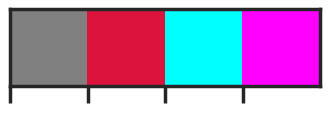

In [3]:
pal=sns.blend_palette(['gray','crimson', 'cyan', 'magenta'],4)
sns.palplot(pal)
sns.set_palette(pal)

In [4]:
plt.rcdefaults()

# Load some necessary variables

In [5]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1100)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1100-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1100-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 200.0 80.0 140.0


In [6]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

In [7]:

yes_save_plots = 0


---

# First, load in the array
Because of how big the arrays are (have all mice, all trials, all channels, and all samples) the jupyter notbook memory is limited to only loading one scenario at a time

In [8]:
scenario = input('what situation (rew, rew2, unrew, novel): ') #rew, rew2, unrew, novel

if scenario == "rew":
    all_rew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\all_trials_arrays\alltrl_rew.npy")
    print('rew: {0}'.format(all_rew_arr.shape))
    
elif scenario == "rew2":
    all_rew2_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\all_trials_arrays\alltrl_rew2.npy")
    print('rew2: {0}'.format(all_rew2_arr.shape))
    
elif scenario == "unrew":
    all_unrew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\all_trials_arrays\alltrl_unrew.npy")
    print('unrew: {0}'.format(all_unrew_arr.shape))
    
elif scenario == "novel":
    all_novel_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\all_trials_arrays\alltrl_novel.npy")
    print('novel: {0}'.format(all_novel_arr.shape))


what situation (rew, rew2, unrew, novel):  rew


rew: (18, 80, 384, 7350)


In [9]:
if scenario == 'novel':
    nov_pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\all_trials_arrays\cctrl_ls_novel"
    open_file = open(nov_pkl_file, "rb")
    CC_ls = pickle.load(open_file)
    open_file.close()
    len(CC_ls)
else:
    pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\all_trials_arrays\cctrl_ls"
    open_file = open(pkl_file, "rb")
    CC_ls = pickle.load(open_file)
    open_file.close()
    len(CC_ls)

# Define some functions

In [10]:
def VEP_lines(data_array, CC_ls):
    groupA = []
    groupB = []
    for i in range(data_array.shape[0]):
        if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
            groupA.append(data_array[i])
        elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
            groupB.append(data_array[i])

    groupA_arr = np.array(groupA)
    groupB_arr = np.array(groupB)
    mean_A = groupA_arr.mean(axis=1).mean(axis=0) #mean across trials per mouse, then across all mice
    mean_B = groupB_arr.mean(axis=1).mean(axis=0) #mean across trials per mouse, then across all mice

    V1_A = mean_A[200:300, :]
    min_v1A = np.where(V1_A == np.amin(V1_A))
    min_v1ch_A = min_v1A[0][0] + 199
    V1_B = mean_B[200:300, :]
    min_v1B = np.where(V1_B == np.amin(V1_B))
    min_v1ch_B = min_v1B[0][0] + 199
    
    HPC_A = mean_A[80:200, :]
    min_HPC_A = np.where(HPC_A == np.amin(HPC_A))
    min_hpcch_A = min_HPC_A[0][0] + 79
    HPC_B = mean_B[80:200, :]
    min_HPC_B = np.where(HPC_B == np.amin(HPC_B))
    min_hpcch_B = min_HPC_B[0][0] + 79
    
    return groupA_arr, groupB_arr, mean_A, mean_B, min_v1ch_A, min_v1ch_B, min_hpcch_A, min_hpcch_B

### Second, apply the function to the scenario

In [11]:

if scenario == "rew":
    plt_title = "Rewarded with Water - Average"
    wt_alltr, fx_alltr, wt_mean, fx_mean, wt_v1ch, fx_v1ch, wt_hpcch, fx_hpcch = VEP_lines(all_rew_arr, CC_ls)
elif scenario == "rew2":
    plt_title = "Rewarded without Water - Average"
    wt_alltr, fx_alltr, wt_mean, fx_mean, wt_v1ch, fx_v1ch, wt_hpcch, fx_hpcch = VEP_lines(all_rew2_arr, CC_ls)
elif scenario == "unrew":
    plt_title = "Unrewarded- Average"
    wt_alltr, fx_alltr, wt_mean, fx_mean, wt_v1ch, fx_v1ch, wt_hpcch, fx_hpcch = VEP_lines(all_unrew_arr, CC_ls)
elif scenario == "novel":
    plt_title = "Novel - Average"
    wt_alltr, fx_alltr, wt_mean, fx_mean, wt_v1ch, fx_v1ch, wt_hpcch, fx_hpcch = VEP_lines(all_novel_arr, CC_ls)


In [12]:
wt_ets, fx_ets = [], []
for i in range(len(CC_ls)):
    if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
        wt_ets.append(CC_ls[i])
    elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
        fx_ets.append(CC_ls[i])
        
print(len(wt_ets), len(fx_ets))

10 8


### Finally, you can plot VEP line plots if you want

In [13]:
wt_alltr.shape # #mice x #trials x #channels x #samples

(10, 80, 384, 7350)

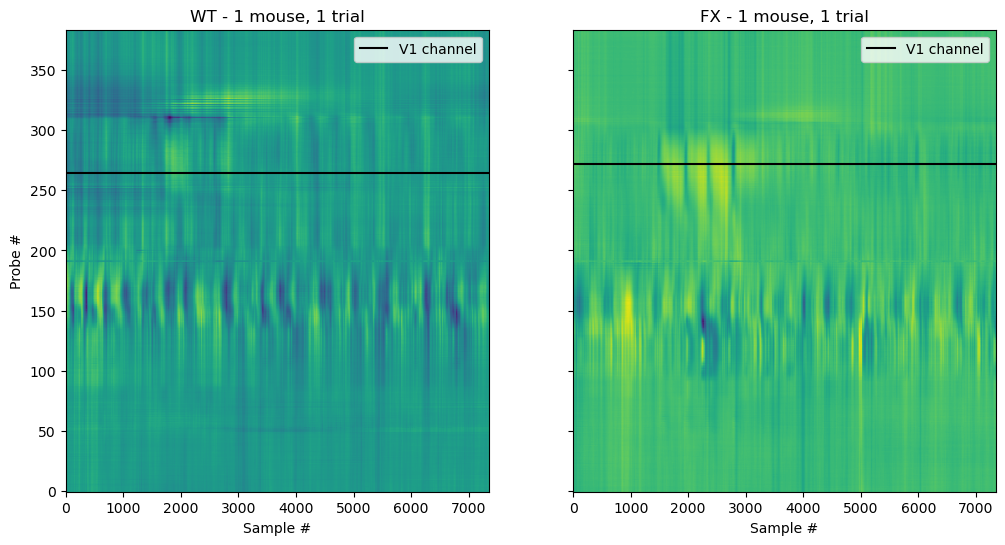

In [14]:
fig,ax = plt.subplots(1,2, figsize=(12,6), sharey=True, sharex=True)

ax[0].imshow(wt_alltr[0][10], aspect='auto', origin='lower') #one mouse, 1 trial
ax[1].imshow(fx_alltr[0][10], aspect='auto', origin='lower')

ax[0].set_title('WT - 1 mouse, 1 trial')
ax[1].set_title('FX - 1 mouse, 1 trial')

ax[0].set_ylabel('Probe #')
ax[0].set_xlabel('Sample #')
ax[1].set_xlabel('Sample #')

ax[0].axhline(wt_v1ch, color='black', label='V1 channel')
ax[1].axhline(fx_v1ch, color='black', label='V1 channel')

# ax[0].axhline(wt_hpcch, color='red', label='HPC channel')
# ax[1].axhline(fx_hpcch, color='red', label='HPC channel')

ax[0].legend()
ax[1].legend()

plt.show()

# Trial by trial analysis

In [15]:
#if you want to change the HPC channel, run this cell
my_hpc_channel = 160

wt_hpcch = my_hpc_channel
fx_hpcch = my_hpc_channel

### First, look at the responses in the WT group of mice (V1 and HPC)

In [16]:
vmin, vmax = -400, 400

# for i, data in enumerate(wt_alltr):
#     et = wt_ets[i]
#     v1_vep_alltrials = data[:, wt_v1ch, :]
#     hpc_vep_alltrials = data[:, wt_hpcch, :]
    
#     fig, ax = plt.subplots(1, 2, figsize=(10,3), sharex=True, sharey=True)
#     f1 = ax[0].imshow(v1_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
#     f2 = ax[1].imshow(hpc_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    
#     ax[0].set_ylabel('Trial #')
#     ax[0].set_xlabel('Time (sec)')
#     ax[1].set_xlabel('Time (sec)')
#     fig.suptitle(f'WT {scenario}: {et}_{i}')
#     ax[0].set_title('V1')
#     ax[1].set_title(f'HPC ch{wt_hpcch}')
#     ax[0].set_xticks([1,1250,2500,3750,5000,6250])
#     ax[0].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5])
    
#     cb_tf = fig.add_axes([.92, 0.15, 0.02, 0.7])
#     cb_tf = fig.colorbar(f1, cax=cb_tf, ticks=range(vmin,vmax+1,100))
#     cb_tf.set_label('LFP (uV)')
    
#     plt.show()
    

### Now look at the WT average across mice

In [17]:
my_data = wt_alltr.mean(axis=0)

v1_vep_alltrials = my_data[:, wt_v1ch, :]
hpc_vep_alltrials = my_data[:, wt_hpcch, :]

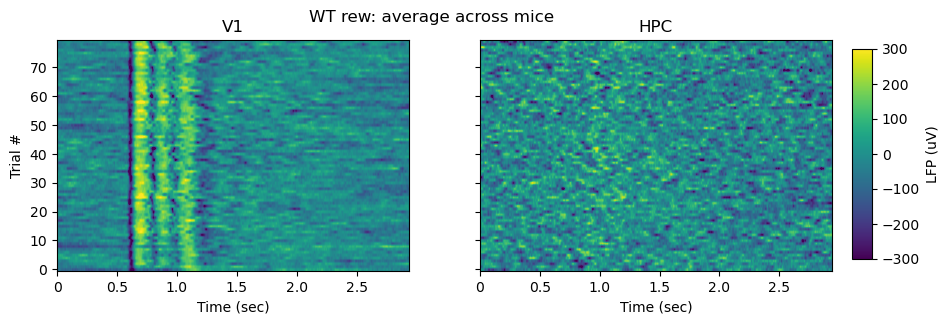

In [18]:
vmin, vmax = -300, 300

fig, ax = plt.subplots(1, 2, figsize=(10,3), sharex=True, sharey=True)
f1 = ax[0].imshow(v1_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto', cmap='viridis')
f2 = ax[1].imshow(hpc_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto', cmap='viridis')

ax[0].set_ylabel('Trial #')
ax[0].set_xlabel('Time (sec)')
ax[1].set_xlabel('Time (sec)')
fig.suptitle(f'WT {scenario}: average across mice')
ax[0].set_title('V1')
ax[1].set_title('HPC')
ax[0].set_xticks([1,1250,2500,3750,5000,6250])
ax[0].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5])

cb_tf = fig.add_axes([.92, 0.15, 0.02, 0.7])
cb_tf = fig.colorbar(f1, cax=cb_tf, ticks=range(vmin,vmax+1,100))
cb_tf.set_label('LFP (uV)')

# Change the end of this next line with a new file name!!
if yes_save_plots == 1:
    file_name = f"LFPheat_alltrls_wt_{scenario}.pdf"
    out_path = r"C:\Users\AChub_Lab\Desktop\trlbytrl_plv_plots\trl_by_trl"+"\\"+file_name
    plt.savefig(out_path, transparent=True)

plt.show()

### Second, look at the responses in the FX group of mice (V1 and HPC)

In [19]:
vmin, vmax = -400, 400

# for i, data in enumerate(fx_alltr):
#     et = fx_ets[i]
#     v1_vep_alltrials = data[:, fx_v1ch, :]
#     hpc_vep_alltrials = data[:, fx_hpcch, :]
    
#     fig, ax = plt.subplots(1, 2, figsize=(10,3), sharex=True, sharey=True)
#     f1 = ax[0].imshow(v1_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
#     f2 = ax[1].imshow(hpc_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    
#     ax[0].set_ylabel('Trial #')
#     ax[0].set_xlabel('Time (sec)')
#     ax[1].set_xlabel('Time (sec)')
#     fig.suptitle(f'FX {scenario}: {et}_{i}')
#     ax[0].set_title('V1')
#     ax[1].set_title(f'HPC ch{fx_hpcch}')
#     ax[0].set_xticks([1,1250,2500,3750,5000,6250])
#     ax[0].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5])
    
#     cb_tf = fig.add_axes([.92, 0.15, 0.02, 0.7])
#     cb_tf = fig.colorbar(f1, cax=cb_tf, ticks=range(vmin,vmax+1,100))
#     cb_tf.set_label('LFP (uV)')
    
#     plt.show()
    

### Now look at the FX average across mice

In [20]:
my_data = fx_alltr.mean(axis=0)

v1_vep_alltrials = my_data[:, fx_v1ch, :]
hpc_vep_alltrials = my_data[:, fx_hpcch, :]

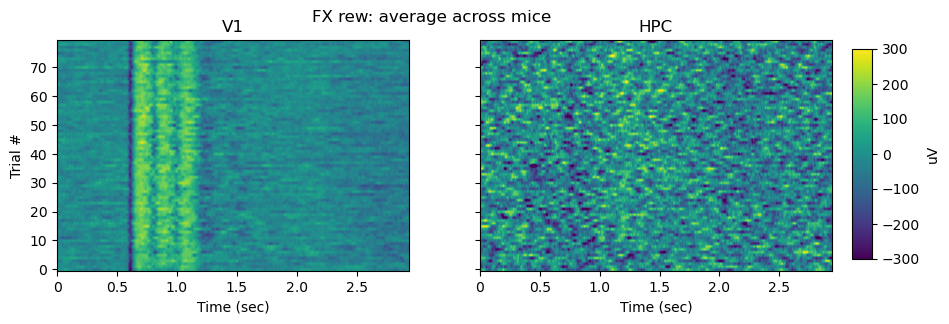

In [21]:
vmin, vmax = -300, 300

fig, ax = plt.subplots(1, 2, figsize=(10,3), sharex=True, sharey=True)
f1 = ax[0].imshow(v1_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto', cmap='viridis')
f2 = ax[1].imshow(hpc_vep_alltrials, vmin=vmin, vmax=vmax, origin='lower', aspect='auto', cmap='viridis')

ax[0].set_ylabel('Trial #')
ax[0].set_xlabel('Time (sec)')
ax[1].set_xlabel('Time (sec)')
fig.suptitle(f'FX {scenario}: average across mice')
ax[0].set_title('V1')
ax[1].set_title('HPC')
ax[0].set_xticks([1,1250,2500,3750,5000,6250])
ax[0].set_xticklabels([0,0.5,1.0,1.5,2.0,2.5])

cb_tf = fig.add_axes([.92, 0.15, 0.02, 0.7])
cb_tf = fig.colorbar(f1, cax=cb_tf, ticks=range(vmin,vmax+1,100))
cb_tf.set_label('uV')

# Change the end of this next line with a new file name!!
if yes_save_plots == 1:
    file_name = f"LFPheat_alltrls_fx_{scenario}.pdf"
    out_path = r"C:\Users\AChub_Lab\Desktop\trlbytrl_plv_plots\trl_by_trl"+"\\"+file_name
    plt.savefig(out_path, transparent=True)

plt.show()

## Trials grouped into average across 5

In [22]:
# Trials grouped into average across 5
def butter_bandpass_filter(data, lowcutoff=4, highcutoff=8, fs=2500, order=6):
    nyq = 0.5 * fs  # Nyquist Frequency
    high_cutoff = highcutoff / nyq
    low_cutoff = lowcutoff / nyq
    # Get the filter coefficients 
    b, a = sig.butter(order, high_cutoff, btype='low', analog=False)
    y = sig.filtfilt(b, a, data)
    b2, a2 = sig.butter(order, low_cutoff, btype='high', analog=False)
    y2 = sig.filtfilt(b2, a2, y)
    return y2

In [23]:
def trl_avg_plots(all_array, group, v1_ch, hpc_ch, plt_title='training', bp_filt=0, trl_group=5, plot_factor=300, is_plot=False):
    """
    __version_1.0__ - 05.19.2023 - mz
    
    This function works to plot the average response for different groups of recordings throughout the session.
    Essentially it's aim is to plot the LFPs of a V1 and HPC channel across the entirety of the session.
    Also, it uses the above function "butter_bandpass_filter" if bp_filt == 1.
    
    INPUTS
        all_array - array in the form of (mice x trials x channels x samples)
        group - string defining the genotype of the group, used for saving the plots
        v1_ch, hpc_ch - channel number to use for each respective brain region
        plt_title - str that is used for plotting title
        bp_filt - 0 or 1; binary no or yes for theta bandpass filtering the data
        trl_group - # of trials you want binned together
        plot_factor - adjusts how spread out the plot traces are in the y-dimension
    OUTPUT
        v1_trls - V1 array with the binned LFP traces (bins x samples)
        hpc_trls - HPC array with the binned LFP traces (bins x samples)
    """
    
    mean_mice_post = all_array.mean(axis=0) #mean across mice

    tot_trls = mean_mice_post.shape[0]
    trlch_v1, trlch_hpc = v1_ch, hpc_ch
    trls = np.arange(0,tot_trls+1,trl_group)

    v1_trls, hpc_trls = [], []
    for i in range(0,len(trls)-1):
        trl_group_avg = mean_mice_post[trls[i]:trls[i+1],:,:].mean(axis=0) #mean across every n# of trials
        v1_trace = trl_group_avg[trlch_v1,:]
        v1_time = np.linspace(0, v1_trace.shape[0]/sr, v1_trace.shape[0])
        hpc_trace = trl_group_avg[trlch_hpc,:]
        hpc_time = np.linspace(0, hpc_trace.shape[0]/sr, hpc_trace.shape[0])
        if bp_filt == 1:
            v1_trace = butter_bandpass_filter(v1_trace)
            hpc_trace = butter_bandpass_filter(hpc_trace)
            plot_factor = 150
        v1_trls.append(v1_trace)
        hpc_trls.append(hpc_trace)

    y_trials = np.arange(0,len(v1_trls),1)*plot_factor
    fig, ax = plt.subplots(1, 2, figsize=(12,4*1), sharex=True)
    for i in range(0,len(trls)-1):
        ax[0].plot(v1_time, v1_trls[i]+i*plot_factor, 
                   label=f'{int(y_trials[i]/plot_factor)}: Trials [{trls[i]}:{trls[i+1]})')
        ax[0].set_title(f'V1 ch{trlch_v1}')
        ax[0].set_xlabel('Time (s)')
        ax[0].set_ylabel('Group # response (uV)')
        ax[0].set_yticks(y_trials)
        ax[0].set_yticklabels([int(x/plot_factor) for x in y_trials])

        ax[0].axvspan(0.5, 0.7, facecolor='grey', alpha = 0.01)
        ax[1].plot(hpc_time, hpc_trls[i]+i*plot_factor, 
                   label=f'{int(y_trials[i]/plot_factor)}: Trials [{trls[i]}:{trls[i+1]})')
        ax[1].set_title(f'HPC ch{trlch_hpc}')
        ax[1].set_xlabel('Time (s)')
        ax[1].set_yticks(y_trials)
        ax[1].set_yticklabels([int(x/plot_factor) for x in y_trials])
        ax[1].axvspan(0.5, 0.7, facecolor='grey', alpha = 0.01)
    plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
    plt.suptitle(plt_title)
    
    # Change the end of this next line with a new file name!!
    if is_plot:
        file_name = f"LFP_grouptrls_{group}_{scenario}.pdf"
        out_path = r"C:\Users\AChub_Lab\Desktop\trlbytrl_plv_plots\trl_by_trl"+"\\"+file_name
        plt.savefig(out_path, transparent=True)
    sns.despine()
    plt.show()
    
    return np.array(v1_trls), np.array(hpc_trls)

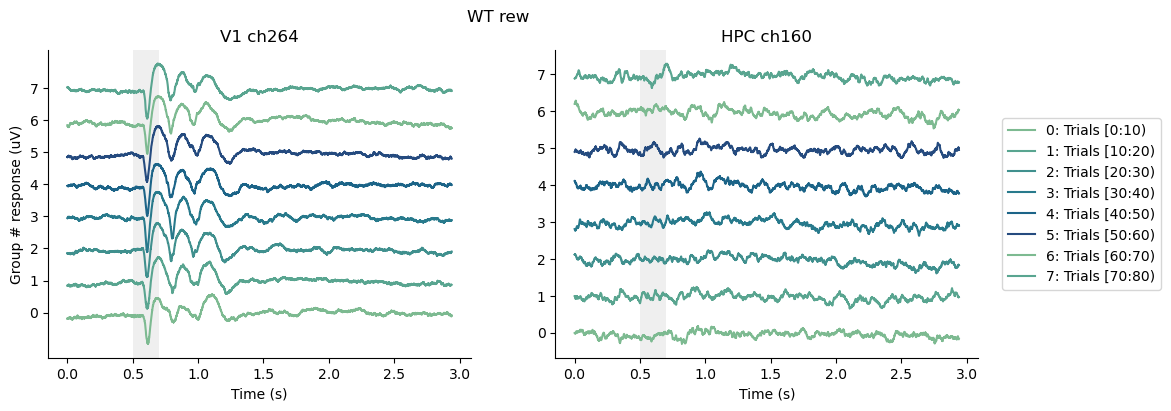

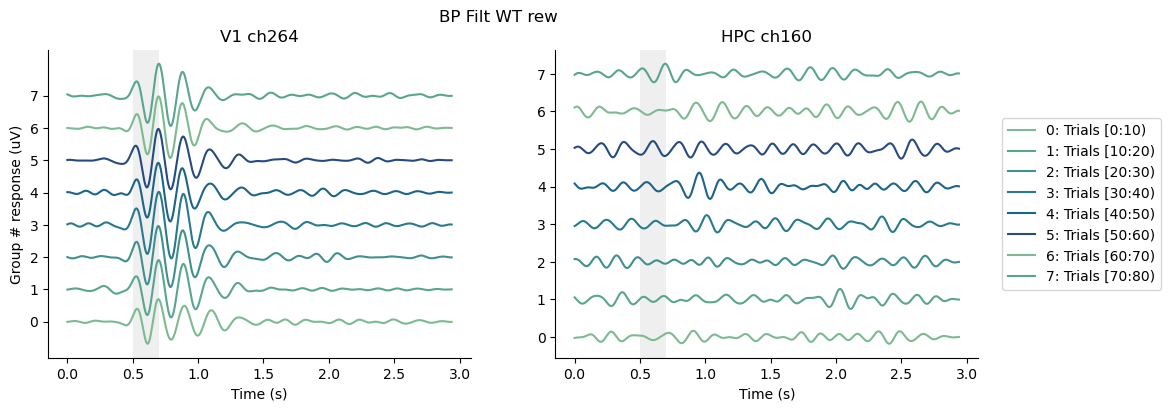

In [24]:
sns.set_palette('crest')
for iii in [0,1]:
    foo_title = str(f'WT {scenario}') if iii==0 else str(f'BP Filt WT {scenario}')
    sc_wt_v1, sc_wt_hpc = trl_avg_plots(wt_alltr, v1_ch=wt_v1ch, hpc_ch=wt_hpcch,
                                        group='wt', 
                                        plt_title=foo_title, 
                                        bp_filt=iii, 
                                        trl_group=10, 
                                        is_plot=yes_save_plots)

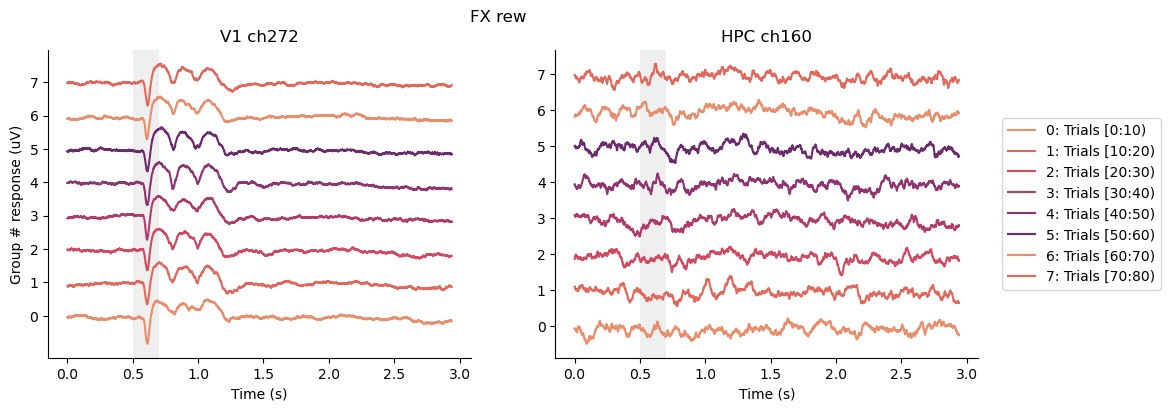

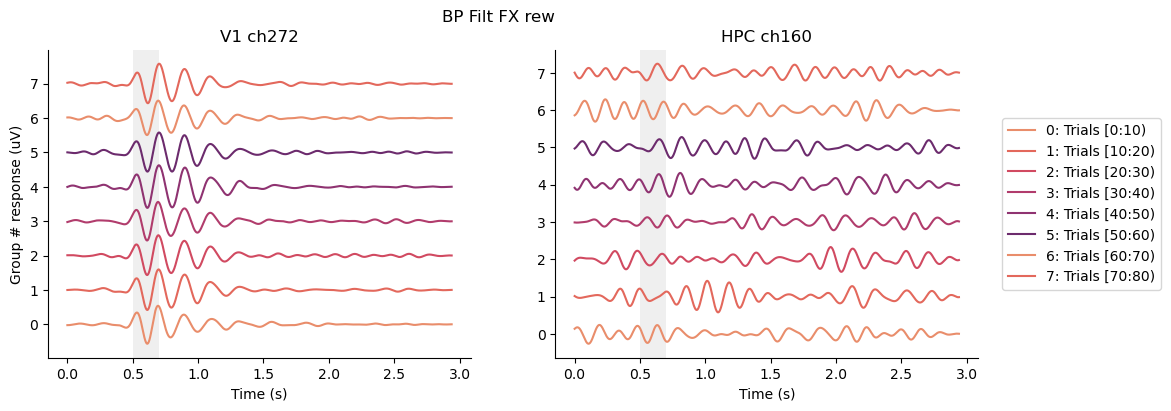

In [25]:
sns.set_palette('flare')
for iii in [0,1]:
    foo2_title = str(f'FX {scenario}') if iii==0 else str(f'BP Filt FX {scenario}')
    sc_fx_v1, sc_fx_hpc = trl_avg_plots(fx_alltr, v1_ch=fx_v1ch, hpc_ch=fx_hpcch,
                                        group='fx', 
                                        plt_title=foo2_title, 
                                        bp_filt=iii, 
                                        trl_group=10, 
                                        is_plot=yes_save_plots)

---

---

---

---

---

# Save the arrays for plv

In [26]:
#plotting each mouse
wt_allmouse_mean = wt_alltr.mean(axis=1) #mean across trials for each mouse
fx_allmouse_mean = fx_alltr.mean(axis=1) #mean across trials for each mouse

print(f'WT shape: {wt_allmouse_mean.shape} --- FX shape: {fx_allmouse_mean.shape}')

WT shape: (10, 384, 7350) --- FX shape: (8, 384, 7350)


In [27]:
arr_out_path = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd"
wt_Fname = f"wt_allmouse_mean_{scenario}.npy"
fx_Fname = f"fx_allmouse_mean_{scenario}.npy"

wt_out_path = arr_out_path + '\\' + wt_Fname
fx_out_path = arr_out_path + '\\' + fx_Fname

np.save(wt_out_path, wt_allmouse_mean)
np.save(fx_out_path, fx_allmouse_mean)

---

# Now move to the PLV analysis
This essentially just creates the dataframes for analysis on other notebooks

In [28]:
def calc_plv(x, y, num_samples=7350, 
             Sampling_Rate=2500,
             base_idx = [0, 400],
             min_freq = 2,
             max_freq = 90,
             num_frex = 40,
             range_cycles = [3, 10]
            ):
    
    #frequencies vector
    frex = np.logspace(np.log10(min_freq),np.log10(max_freq),num_frex)
    time = np.linspace(0, num_samples, int(num_samples) )

    #wavelet parameters
    s = np.divide(np.logspace(np.log10(range_cycles[0]), np.log10(range_cycles[-1]), num_frex), 2*np.pi*frex)
    wavtime = np.linspace(-1, 1, 2*int(Sampling_Rate)+1)
    half_wave = (len(wavtime)-1)/2

    #FFT parameters
    nWave = len(wavtime)

    num_trials= x[:20].shape[0]
    nData = num_trials * num_samples
    nConv = [nWave+nData-1, nWave+nData-1 ,  nWave+num_samples-1 ]

    dataX = {}
    dataY = {}
#             #FFT of total data
    dataX[0] = fft( x[:20].flatten(), nConv[0])
    dataY[0] = fft( y[:20].flatten(), nConv[0])

    tf = np.zeros((len(frex), num_samples) )
    phd = np.zeros((len(frex), num_samples) )
    
    #main loop
    for fi in range(len(frex)):
        # create wavelet and get its FFT
        # the wavelet doesn't change on each trial...
        wavelet  = np.exp(2*1j*np.pi*frex[fi]*wavtime) * np.exp(-wavtime**2/(2*s[fi]**2))    

        # need separate FFT 
        waveletX = fft(wavelet,nConv[0])
        waveletX = waveletX / max(waveletX)

        # notice that the fft_EEG cell changes on each iteration
        a_sig = ifft(waveletX*dataX[0],nConv[0])
        b_sig = ifft(waveletX*dataY[0],nConv[0])

        a_sig = a_sig[int(half_wave): int(len(a_sig)-half_wave)]
        b_sig = b_sig[int(half_wave): int(len(b_sig)-half_wave)]
        aphase = (np.angle(a_sig)+2*np.pi)%(2*np.pi)
        bphase = (np.angle(b_sig)+2*np.pi)%(2*np.pi)
        phased = aphase - bphase
#         phd[fi,:]=(phased.reshape(-1,2000))
        phd[fi,:]=pg.circ_mean(((phased.reshape(-1,num_samples)+2*np.pi)%(2*np.pi)))
        tf[fi,:]=np.abs(np.exp(1j*phased).reshape(-1,num_samples).sum(axis=0))/(phased.reshape(-1,num_samples).shape[0])
        
    return tf, phd

In [29]:
print(wt_alltr.shape) # mice x trials x channels x samples

# wt_v1ch = 268
# fx_v1ch = 266
# wt_hpcch = 112
# fx_hpcch = 112

(10, 80, 384, 7350)


In [30]:
# wt plv
plvdic = []
for mouse, data in enumerate(wt_alltr):
    et = str(mouse) + '_wt'
    v1_channel = data[:, wt_v1ch, :]
    hpc_channel = data[:, wt_hpcch, :]
    tf,phd = calc_plv(v1_channel, hpc_channel)
    plvdic.append((et, tf, phd, 'wt'))
wt_tmpdf=pd.DataFrame(plvdic, columns=['et','plv','phsdiff','group'])
wt_tmpdf.shape

(10, 4)

In [31]:
# fx plv
plvdic = []
for mouse, data in enumerate(fx_alltr):
    et = str(mouse) + '_fx'
    v1_channel = data[:, fx_v1ch, :]
    hpc_channel = data[:, fx_hpcch, :]
    tf,phd = calc_plv(v1_channel, hpc_channel)
    plvdic.append((et, tf, phd, 'fx'))
fx_tmpdf=pd.DataFrame(plvdic, columns=['et','plv','phsdiff','group'])
fx_tmpdf.shape

(8, 4)

In [32]:
# merge wt/fx plv dfs together
wtfx_plv_df = pd.concat([wt_tmpdf,fx_tmpdf])
wtfx_plv_df['situ'] = scenario
wtfx_plv_df.head()

,et,plv,phsdiff,group,situ
0,0_wt,"[[0.34897756219597376, 0.34778428612507595, 0....","[[2.4027173897971585, 2.4038491390397603, 2.40...",wt,rew
1,1_wt,"[[0.41387449399718124, 0.41359414226618874, 0....","[[2.9839608614710906, 2.981825767890659, 2.979...",wt,rew
2,2_wt,"[[0.44766086932420457, 0.4476379221283103, 0.4...","[[2.834502347329314, 2.833825793026557, 2.8331...",wt,rew
3,3_wt,"[[0.2704704119076909, 0.27078169307500916, 0.2...","[[-3.117759681836835, -3.120428586395432, -3.1...",wt,rew
4,4_wt,"[[0.3665911319998597, 0.3664938075892088, 0.36...","[[2.499706478841212, 2.499678338789089, 2.4996...",wt,rew


## Save the df

In [33]:
plv_path = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\plv_phd"
plv_name = f"wtfx_plv_{scenario}.pkl"

out_path = plv_path + '\\' + plv_name

wtfx_plv_df.to_pickle(out_path)

# DONE!!